In [1]:
import pandas as pd
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
df=pd.read_csv(url)
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [2]:
# Check missing values of each column
missing_counts=df.isnull().sum()
print("Missing Values Per Columns:/n",missing_counts[missing_counts>0])

Missing Values Per Columns:/n payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [4]:
# Fill missing numerical column with mean or median
numerical_cols=df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    if df[col].isnull().sum()>0:
        df[col].fillna(df[col].median(),inplace=True)
#Fill missing categorical coulmns with mode
categorical_cols=df.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    if df[col].isnull().sum()>0:
        df[col].fillna(df[col].mode()[0],inplace=True)
print("Missing Values after imputation successfully!")

Missing Values after imputation successfully!


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5048\4196332612.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [5]:
#For columns that are critical and cannot be reasonably imputed, remove rows with missing values to maintain data integrity.
critical_cols=['pickup','dropoff','fare']
df.dropna(subset=critical_cols,inplace=True)
print("Total Missing Values Left:",df.isnull().sum().sum())

Total Missing Values Left: 0


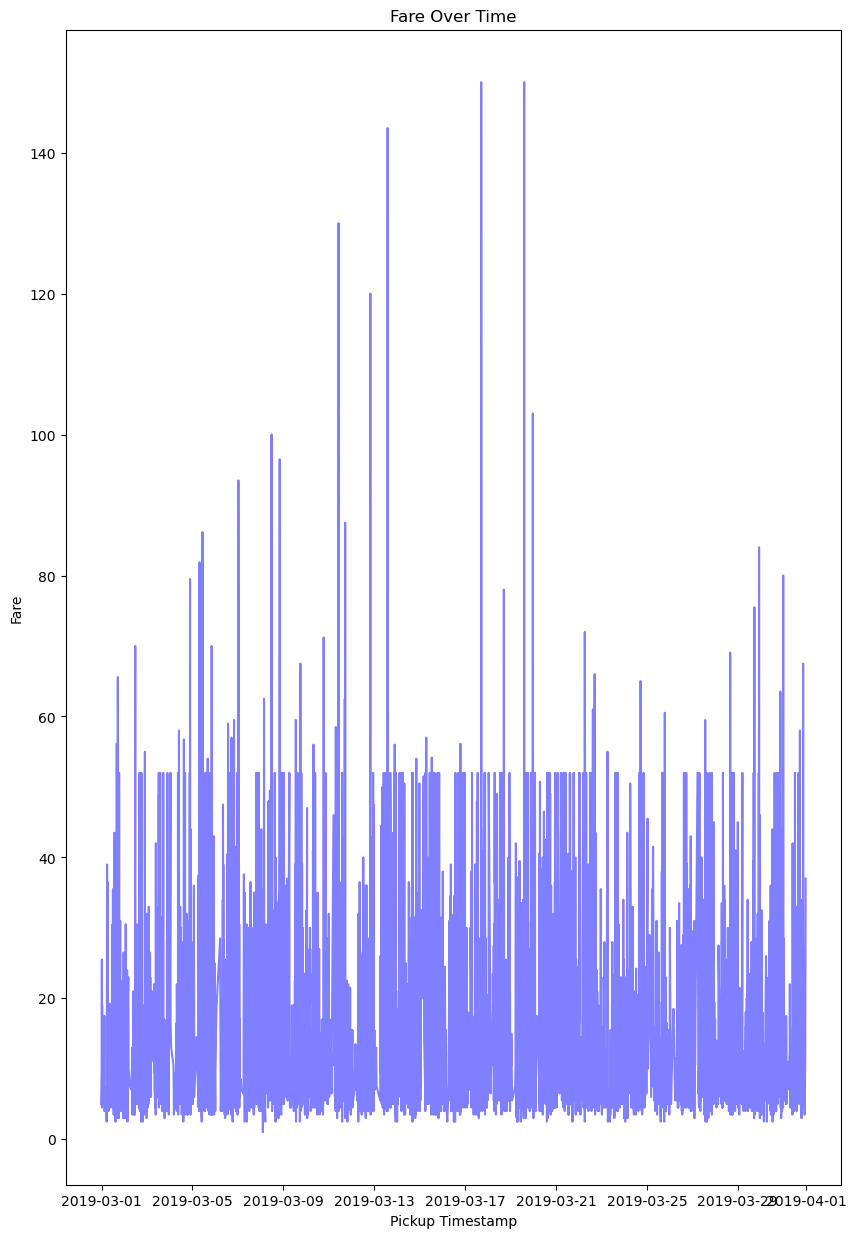

In [5]:
#Line Chart
import pandas as pd
import matplotlib.pyplot as plt
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
df=pd.read_csv(url)
df['pickup']=pd.to_datetime(df['pickup'])
df_sorted=df.sort_values('pickup')
plt.figure(figsize=(10,15))
plt.plot(df_sorted['pickup'],df_sorted['fare'],color='blue',alpha=0.5)
plt.xlabel('Pickup Timestamp')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.show()

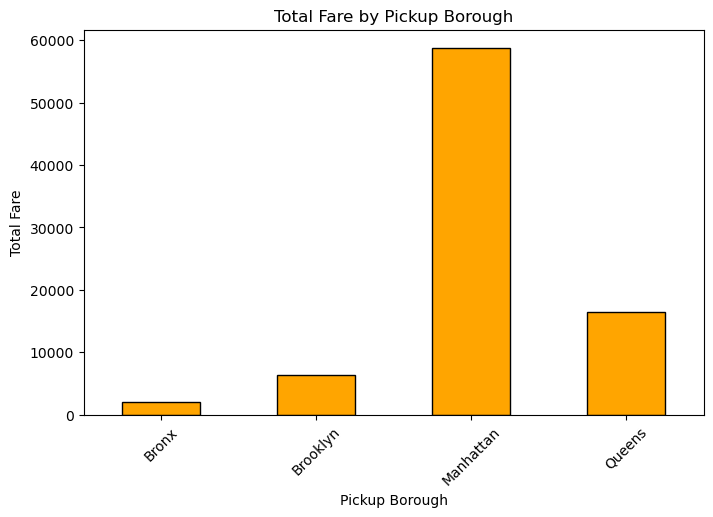

In [6]:
#Bar Chart
import pandas as pd
import matplotlib.pyplot as plt
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
df=pd.read_csv(url)
borough_fare=df.groupby('pickup_borough')['fare'].sum()
borough_fare.plot(kind='bar',figsize=(8,5),color='orange',edgecolor='black')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

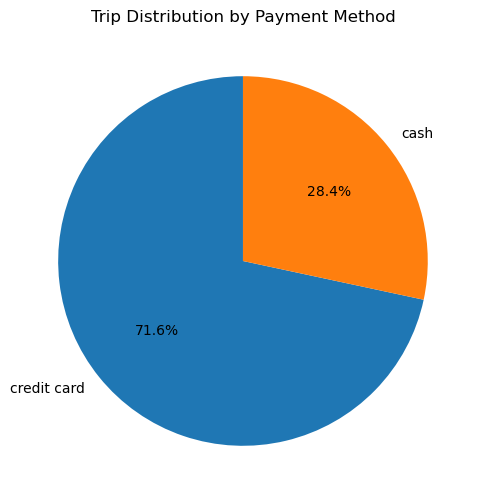

In [7]:
# Pie Chart
payment_counts=df['payment'].value_counts()
plt.figure(figsize=(6,6))
payment_counts.plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.ylabel('')
plt.title('Trip Distribution by Payment Method')
plt.show()

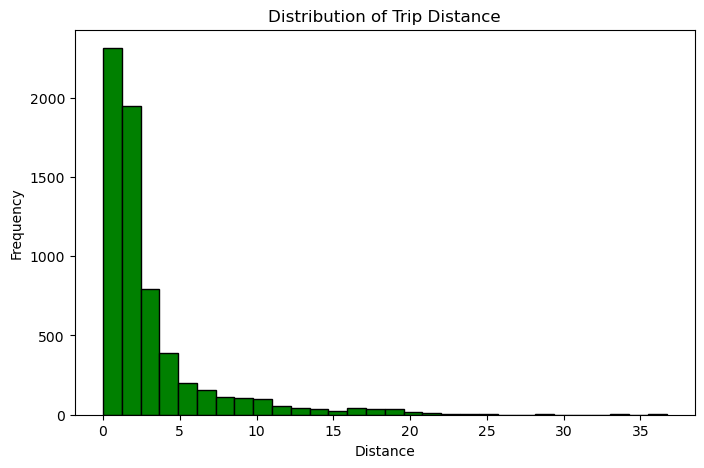

In [8]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['distance'],bins=30,color='green',edgecolor='black')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Distance')
plt.show()

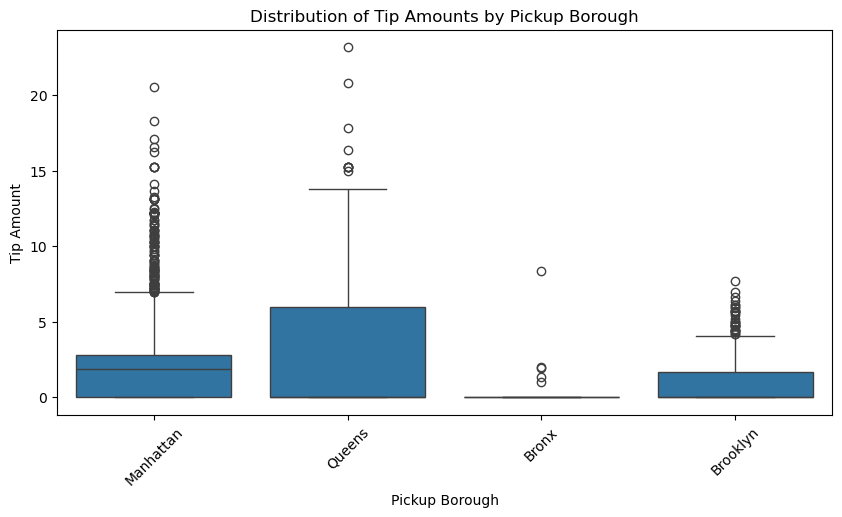

In [11]:
# Box Plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
df=pd.read_csv(url)
plt.figure(figsize=(10,5))
sns.boxplot(x='pickup_borough',y='tip',data=df)
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

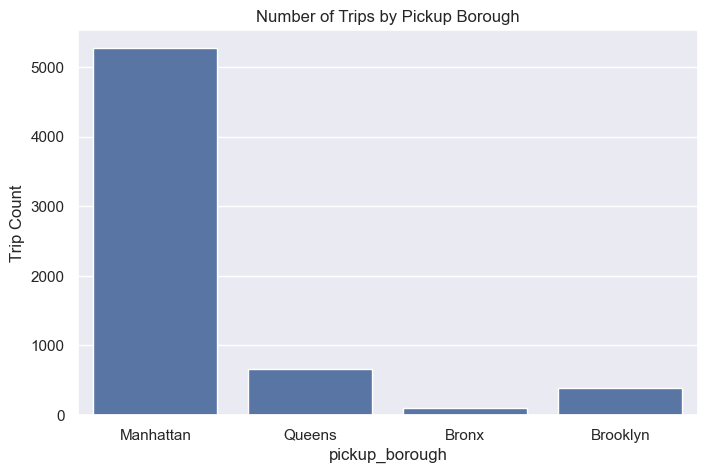

In [13]:
#Visualizations using Seaborn:
#Count Plot
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="pickup_borough")
plt.title("Number of Trips by Pickup Borough")
plt.ylabel("Trip Count")
plt.show()


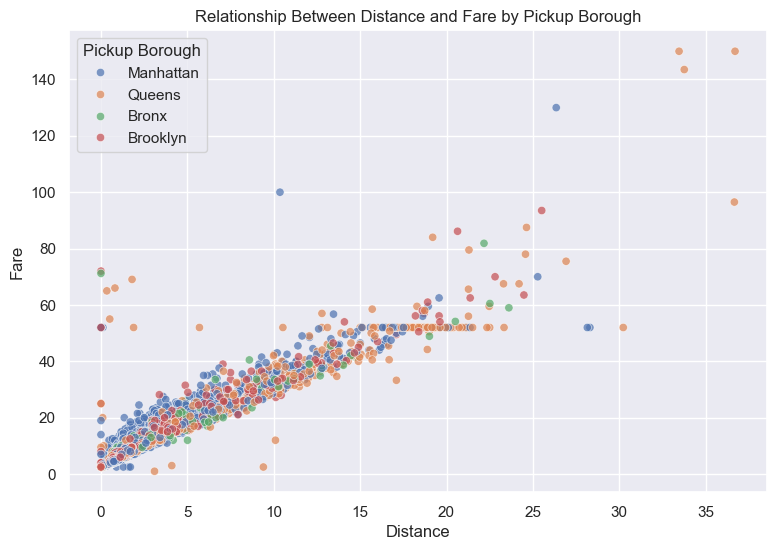

In [14]:
# Scatter 
plt.figure(figsize=(9,6))
sns.scatterplot(data=df,x="distance",y="fare",hue="pickup_borough",alpha=0.7)
plt.title("Relationship Between Distance and Fare by Pickup Borough")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.legend(title="Pickup Borough")
plt.show()

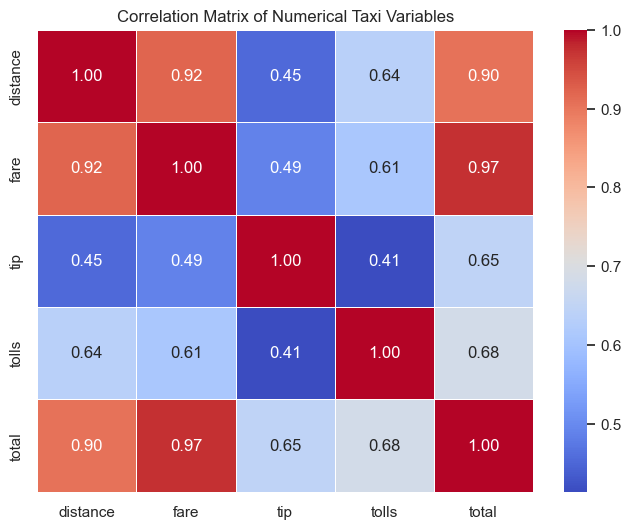

In [16]:
# Heatmap
plt.figure(figsize=(8,6))
num_cols=["distance","fare","tip","tolls","total"]
corr_matrix=df[num_cols].corr()
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix of Numerical Taxi Variables")
plt.show()

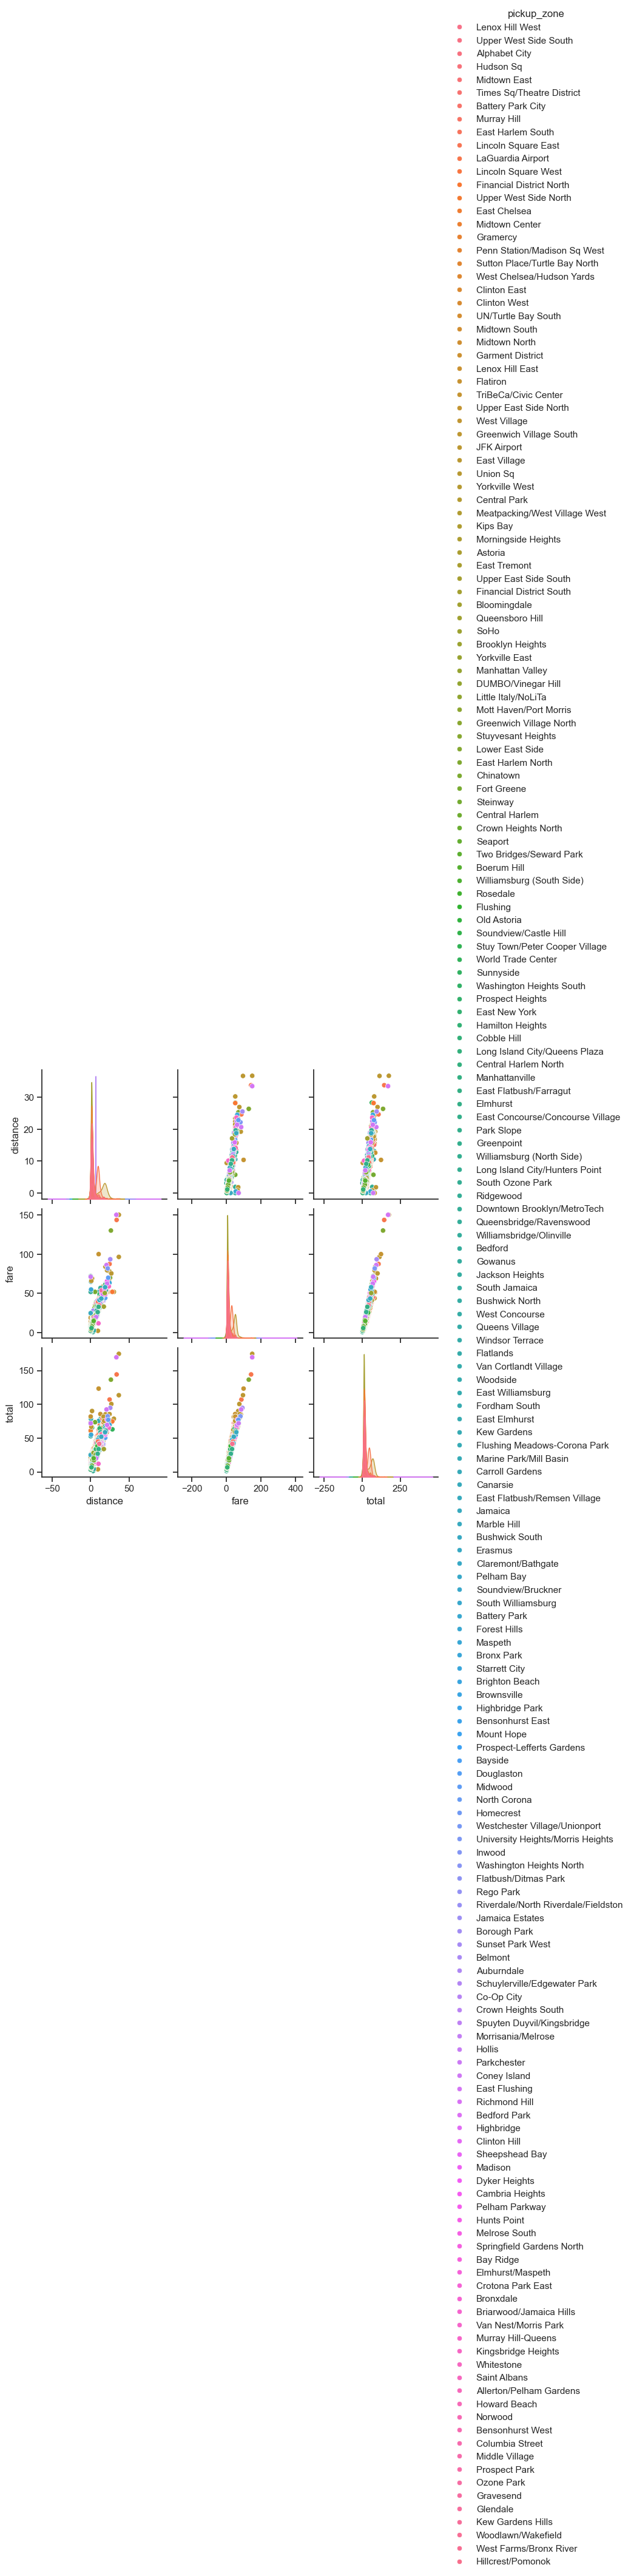

In [17]:
# Pair Plot
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")
pair_cols=["distance","fare","total","pickup_zone"]
sns.pairplot(df[pair_cols],hue="pickup_zone",diag_kind="kde")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7452\2891127408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="payment",y="fare",palette="muted")


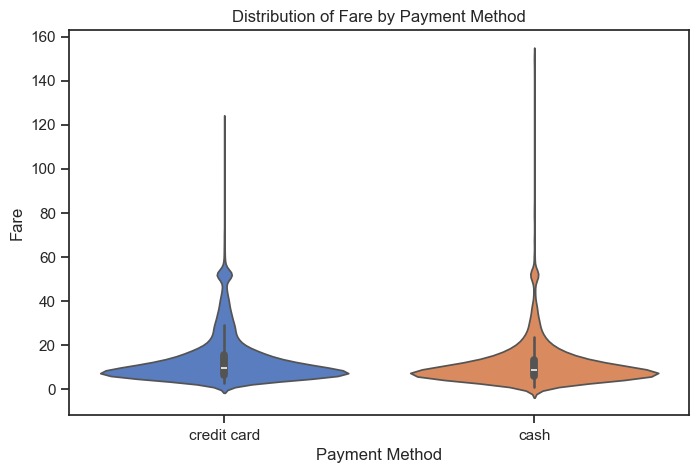

In [18]:
#Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(data=df,x="payment",y="fare",palette="muted")
plt.title("Distribution of Fare by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.show()